In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # matplotlib 기반의 고급 시각화 라이브러리

In [2]:
pip install seaborn

     -------------------------------------- 294.9/294.9 kB 8.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
data=pd.read_csv('C:/a/run/diamonds.csv')
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


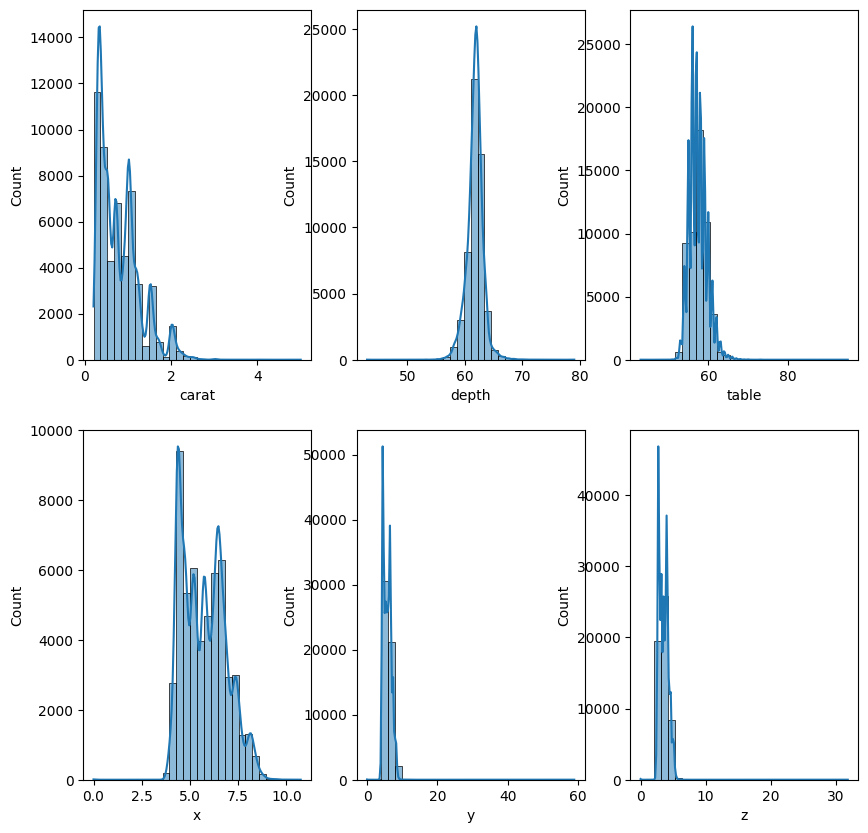

In [5]:
columns=['carat','depth','table','x','y','z']
plt.figure(figsize=(10,10))

for i, columns in enumerate(columns, 1):
    plt.subplot(2,3,i) # 2행 3열 구조로 그래프 배치/ i번째 위치에 그래프 그리기
    sns.histplot(data[columns], kde=True, bins=30) # kde : 커널밀도(곡선: 연속분포)

plt.show()
    
    

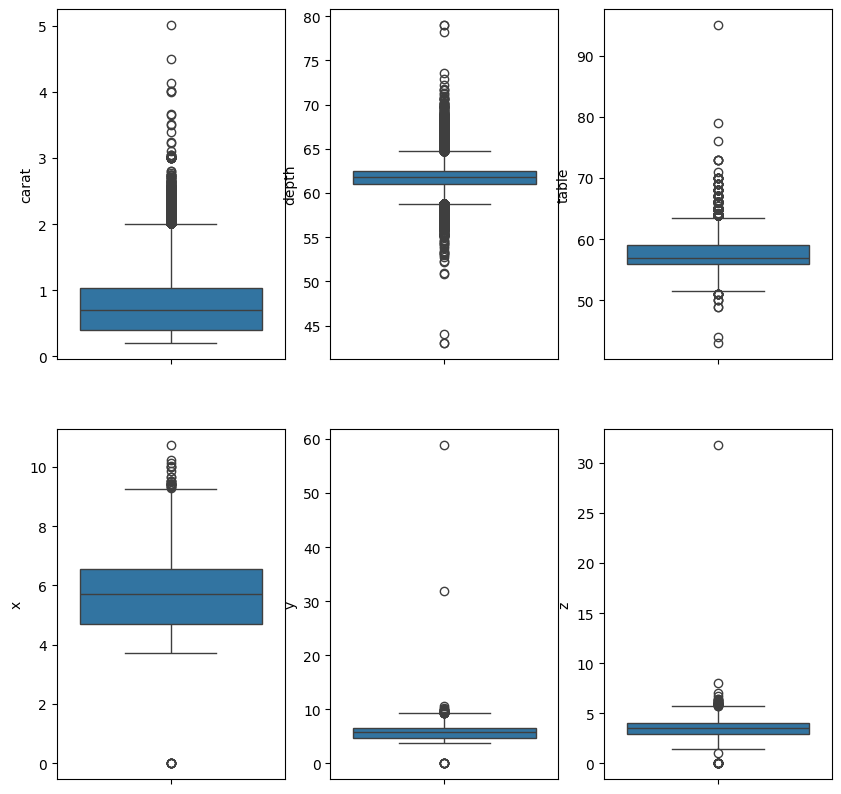

In [10]:
columns=['carat','depth','table','x','y','z']
plt.figure(figsize=(10,10))

for i, columns in enumerate(columns, 1):
    plt.subplot(2,3,i) 
    sns.boxplot(data[columns]) 

plt.show()

In [14]:
columns=['carat','depth','table','x','y','z']

for col in columns:
    Q1=data[col].quantile(0.25) # 사분위수 계산
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1 # 데이터의 중앙 50% 범위

    # IQR의 1.5배 기준으로 이상치 범위 설정
    lower=Q1-1.5*IQR # 하위 이상치
    upper=Q3+1.5*IQR # 상위 이상치

    # 이상치 제거 (lower~upper 사이의 값만 남김) -> 모든 컬럼 이상치 제거
    data=data[(data[col]>=lower)&(data[col]<=upper)]

In [15]:
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


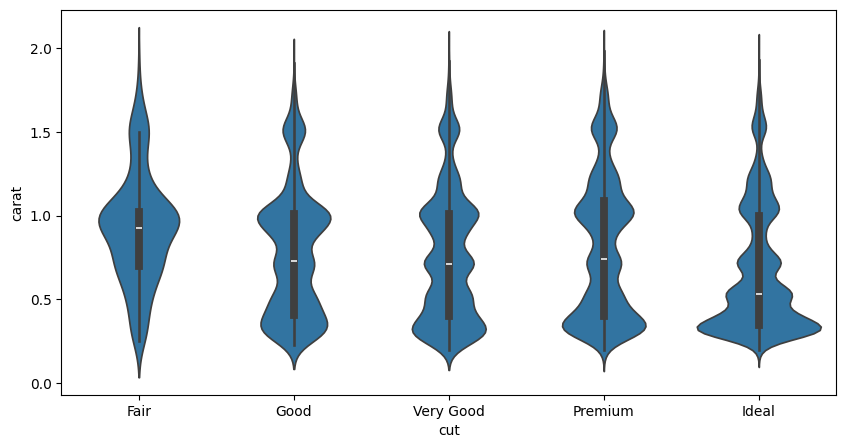

In [16]:
plt.figure(figsize=(10,5))
# kde(외곽 곡선), 박스플롯(중앙값/사분위수)
# order : x축 순서지정
sns.violinplot(x="cut", y="carat", data=data, order=['Fair','Good','Very Good','Premium','Ideal'])
plt.show()

In [17]:
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [21]:
# 불필요한 컬럼 삭제
data.drop('Unnamed: 0', axis=1, inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [25]:
# 인코더 작업 => 범주형 (문자열 -> 숫자로 변환)
from sklearn.preprocessing import LabelEncoder

cut_order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order=['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order=['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

def ordered_label(series, order):
    la=LabelEncoder()
    la.fit(order)
    return la.transform(series)

# 각 컬럼을 순서대로 숫자로 변환
data['cut']=ordered_label(data['cut'], cut_order)
data['color']=ordered_label(data['color'], color_order)
data['clarity']=ordered_label(data['clarity'], clarity_order)


In [27]:
# 피처/타겟(라벨) 분리
features=data.drop('price', axis=1)
label=data['price']

In [31]:
x_col=features.columns
x_col

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='str')

In [34]:
# from sklearn.preprocessing import StandardScaler

# sc=StandardScaler()
# sc_x=sc.fit_transform(features)
# sc_x=pd.DataFrame(sc_x, columns=x_col)
# sc_x

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.281115,-0.667996,-0.912753,-0.521697,-0.277987,-1.119508,-1.624287,-1.608423,-1.642914
1,-1.331946,0.396734,-0.912753,-1.099131,-1.856617,1.867305,-1.683267,-1.746800,-1.833669
2,-1.128622,0.396734,1.476776,0.633173,0.557759,0.373898,-1.378536,-1.361319,-1.324989
3,-1.077791,-1.732726,2.074158,-0.521697,1.393504,0.373898,-1.240916,-1.242710,-1.134233
4,-1.255699,1.461464,2.074158,1.788042,0.929201,-0.123904,-1.634117,-1.628191,-1.563433
...,...,...,...,...,...,...,...,...,...
48686,-0.035757,-0.667996,-1.510135,-1.099131,-0.928011,-0.123904,0.145119,0.150952,0.057987
48687,-0.035757,-1.732726,-1.510135,-1.099131,1.207783,-1.119508,0.086139,0.141068,0.232846
48688,-0.086588,1.461464,-1.510135,-1.099131,0.929201,1.369502,0.056648,0.071879,0.153364
48689,0.320059,0.396734,0.879394,-0.521697,-0.742290,0.373898,0.538320,0.506781,0.439497


In [37]:
# 학습/테스트 분리 한 후 -> 정규화 (데이터 누수라는 문제 있을 수 있어서)
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test=train_test_split(features, label, test_size=0.2, random_state=1)


In [38]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
sc_x_train=sc.fit_transform(X_train)
sc_x_test=sc.transform(X_test)
sc_x

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.281115,-0.667996,-0.912753,-0.521697,-0.277987,-1.119508,-1.624287,-1.608423,-1.642914
1,-1.331946,0.396734,-0.912753,-1.099131,-1.856617,1.867305,-1.683267,-1.746800,-1.833669
2,-1.128622,0.396734,1.476776,0.633173,0.557759,0.373898,-1.378536,-1.361319,-1.324989
3,-1.077791,-1.732726,2.074158,-0.521697,1.393504,0.373898,-1.240916,-1.242710,-1.134233
4,-1.255699,1.461464,2.074158,1.788042,0.929201,-0.123904,-1.634117,-1.628191,-1.563433
...,...,...,...,...,...,...,...,...,...
48686,-0.035757,-0.667996,-1.510135,-1.099131,-0.928011,-0.123904,0.145119,0.150952,0.057987
48687,-0.035757,-1.732726,-1.510135,-1.099131,1.207783,-1.119508,0.086139,0.141068,0.232846
48688,-0.086588,1.461464,-1.510135,-1.099131,0.929201,1.369502,0.056648,0.071879,0.153364
48689,0.320059,0.396734,0.879394,-0.521697,-0.742290,0.373898,0.538320,0.506781,0.439497


In [43]:
from sklearn.metrics import mean_squared_error, r2_score
def eval_data(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_test=model.predict(X_test)
    y_pred_train=model.predict(X_train)

    train_mse1=mean_squared_error(y_train, y_pred_train)
    train_r2_score1=r2_score(y_train, y_pred_train)
    
    test_mse1=mean_squared_error(y_test, y_pred_test)
    test_r2_score1=r2_score(y_test, y_pred_test)

    print(f"MSE:{train_mse1}, r2_score:{train_r2_score1}")
    print(f"MSE:{test_mse1}, r2_score:{test_r2_score1}")

In [44]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

lr=LinearRegression()
eval_data(lr, X_train, X_test, y_train, y_test)

# 회귀분석 -> 과적합 방지 위해 -> 규제 모델 나옴(Ridge/ Lasso/ ElasticNet)
# Ridge : 가중치들의 제곱합을 최소화하는 항 추가(가중치를 전체적으로 줄여주지만 0으로 만들지는 않는다)
# Lasso : 가중치들의 절대값을 최소화하는 항 추가(중요하지 않다고 판단되는 특성의 가중치를 0으로 만듬)
# ElasticNet : Ridge+Lasso


MSE:1392818.0335045173, r2_score:0.8774030587086906
MSE:1367286.8396730789, r2_score:0.8757422299754306


In [46]:
# alpha가 클수록 규제가 강해져 가중치를 0에 가깝게 만든다(과적합 방지)
# alpha가 작을수록 규제가 약해져 일반 선형 회귀에 가까워짐
ridge=Ridge(alpha=1.0)
eval_data(ridge, X_train, X_test, y_train, y_test)

MSE:1392866.000703573, r2_score:0.8773988365980164
MSE:1367401.9743917761, r2_score:0.8757317666381245


In [47]:
lasso=Lasso(alpha=1.0)
eval_data(lasso, X_train, X_test, y_train, y_test)

MSE:1396078.0377639004, r2_score:0.8771161105638627
MSE:1370951.7838985608, r2_score:0.875409163216131


C:\Users\hi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.134e+08, tolerance: 4.425e+07
  model = cd_fast.enet_coordinate_descent(


In [48]:
# alpha : 규제강도
# l1_ratio : 0~1사이의 값 -> 0.5 : lasso, ridge 절반씩 섞음
el=ElasticNet(alpha=1.0, l1_ratio=0.5)
eval_data(el, X_train, X_test, y_train, y_test)

MSE:2523808.8756053713, r2_score:0.7778523532075781
MSE:2446570.787191882, r2_score:0.7776578978143263


In [55]:
# 교차검증
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

def eval_cv(model, features, label, cv=5):
    kf=KFold(n_splits=cv, shuffle=True, random_state=1)

    # 교차검증 수행(k-fold 교차검증으로 5번 평가)
    r2_score=cross_val_score(model, features, label, cv=kf, scoring="r2")
    # 각 fold에서 나온 성능(r2) vudrbs
    mean_r2_score=np.mean(r2_score)
    print(mean_r2_score)

In [58]:
eval_cv(lr, X_test, y_test, cv=5)
eval_cv(ridge, X_test, y_test, cv=5)
eval_cv(lasso, X_test, y_test, cv=5)
eval_cv(el, X_test, y_test, cv=5)

0.8752310367551284
0.8753790200765629
0.8753647167579361
0.7753484440017406


C:\Users\hi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.734e+07, tolerance: 8.657e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\hi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.816e+08, tolerance: 8.366e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\hi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

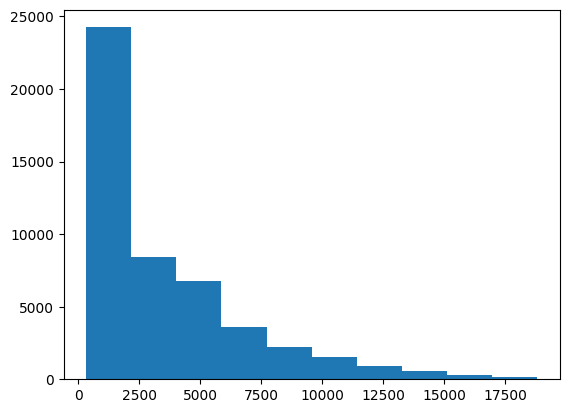

In [61]:
plt.hist(label)
plt.show()

# y가 한쪽으로 치우친 분포 -> 로그변환으로 스케일 안정화

In [63]:
# x=np.exp(3)
# y=np.log1p(x) #log(1+20.0855...) # log보다 log1p 사용(무한대에러발생 안하기 때문) 
# print(y)

3.048587351573742


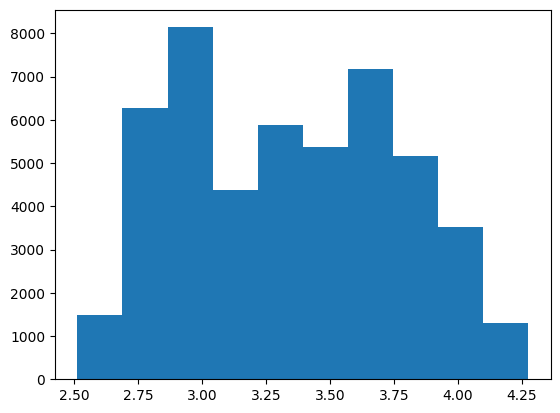

In [64]:
eq=np.log10(label)
plt.hist(eq)
plt.show()